##**Predictive Analytics Using Historical Data**

##**Project Overview**

Predictive Analytics uses historical data, statistical techniques, and machine learning algorithms to predict future outcomes.

In this project, historical sales data is analyzed to identify trends and build a machine learning model that predicts future sales performance.

The project involves data preprocessing, exploratory data analysis, feature engineering, model development, evaluation, and visualization of predictions.

##**Objective**

The main objectives of this project are:

- Clean and preprocess historical sales data

- Analyze sales trends and patterns

- Build a predictive regression model

- Evaluate model performance using accuracy metrics

- Visualize actual and predicted sales values



##**Machine Learning Approach**

A Random Forest Regression model is used to predict sales based on historical features such as quantity, discount, region, and time-based information.

This project demonstrates how machine learning can help businesses make data-driven forecasting decisions.



In [ ]:
#import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

##**Load Dataset**

The Superstore Sales dataset contains historical sales records including order dates, product categories, regions, quantity, discounts, and sales values.

The dataset is used to analyze past trends and train a predictive model.

In [ ]:
#load dataset

df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Quarter'],
      dtype='object')

##**Dataset Understanding**


In [ ]:
#Check rows and columns

df.shape

(9994, 21)

In [ ]:
#Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
#Statistical summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


##**Data Cleaning & Preprocessing**

Data preprocessing is performed to improve data quality before applying machine learning algorithms.

Steps:
- Checking missing values
- Removing duplicate records
- Converting date columns
- Encoding categorical variables

##**Checking Missing Values**

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


##**Remove Duplicate Values**

In [ ]:
df.drop_duplicates(inplace=True)

##**Data Feature Engineering**


In [ ]:
#convert order date
df["Order Date"] = pd.to_datetime(df["Order Date"])

#extract date features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter

print("\nDataFrame Info after date conversion and feature extraction:")
df.info()
print("\nDataFrame Head with new date features:")
display(df.head())


DataFrame Info after date conversion and feature extraction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category  

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


#**Exploratory Data Analysis**

##**Sales Trend Analysis**

This analysis helps understand how sales change over time and identify trends or patterns in historical sales data.

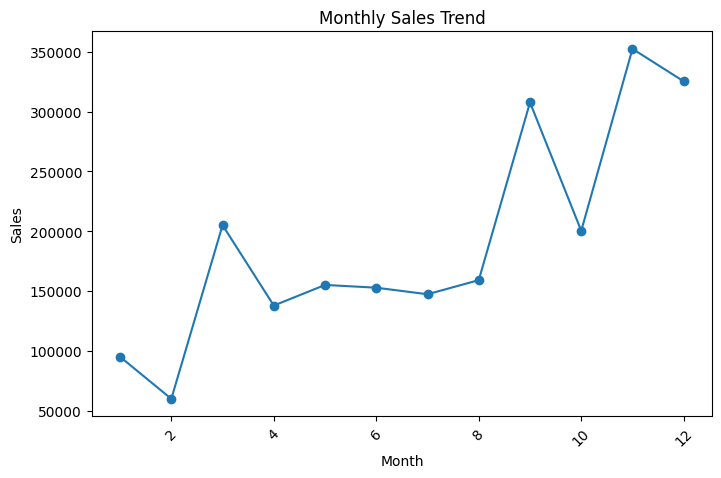

In [ ]:
monthly_sales = (
    df.groupby("Month")["Sales"].sum()
)

plt.figure(figsize=(8,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker= "o"
)

plt.xticks(rotation = 45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

##**Category Sales Analysis**

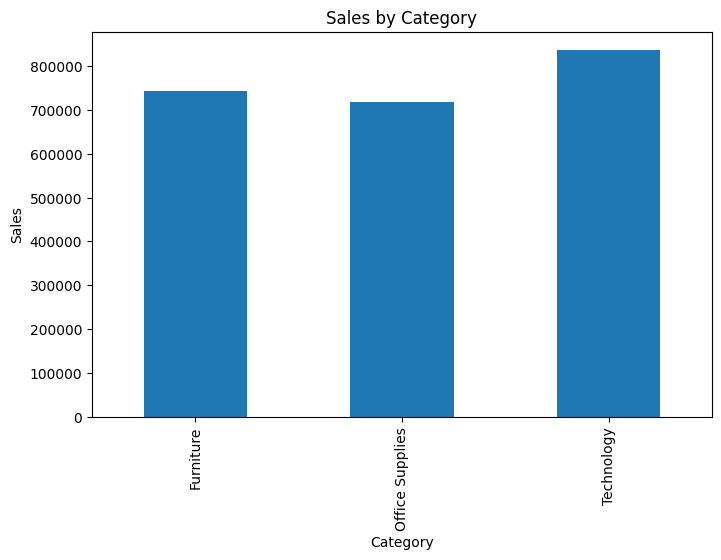

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"].sum()
)

plt.figure(figsize=(8,5))

category_sales.plot(
    kind = "bar"
)

plt.title(
    "Sales by Category"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Sales"
)

plt.show()


#**Encoding Category**


##**Feature Preparation**

Machine learning models require numerical inputs, therefore categorical features are converted into numerical format.

In [ ]:
encoder = LabelEncoder()

categorical_columns = [
    "Category",
    "Region",
    "Segment"
]

for col in categorical_columns:
  df[col] = encoder.fit_transform(
      df[col]
  )

##**Selecting Features**

In [ ]:
#input features

X = df[
    [
     "Year",
     "Month",
     "Quantity",
     "Discount",
     "Category",
      "Region",
      "Segment"
    ]
]

#target variable

y = df["Sales"]

##**Dataset Splitting**

The dataset is divided into training and testing data.

Training data is used to train the model, while testing data evaluates model performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

##**Model Training**

Random Forest Regression is applied because it can capture complex relationships between input features and sales values.

In [ ]:
model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

##**Prediction**

In [ ]:
#predict sales

y_pred = model.predict(
    X_test
)

y_pred[:10]

array([244.94524   ,  32.26349714, 156.04225   , 524.57959333,
       240.88332   ,  96.58039333, 318.61026   , 204.05083738,
        12.236408  , 160.19314   ])

##**Model Evaluation**

##**Model Evaluation**

The model performance is measured using:

- MAE: Average prediction error

- RMSE: Difference between actual and predicted values

- R² Score: Model accuracy

In [ ]:
mae = np.sqrt(
    mean_absolute_error(
        y_test,
        y_pred
    )
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)

print("RMSE:", rmse)

print("R² Score:", r2)

MAE: 16.722752347513453
RMSE: 797.427061130956
R² Score: -0.07650384131812027


##**Actual vs Predicted Visualization**


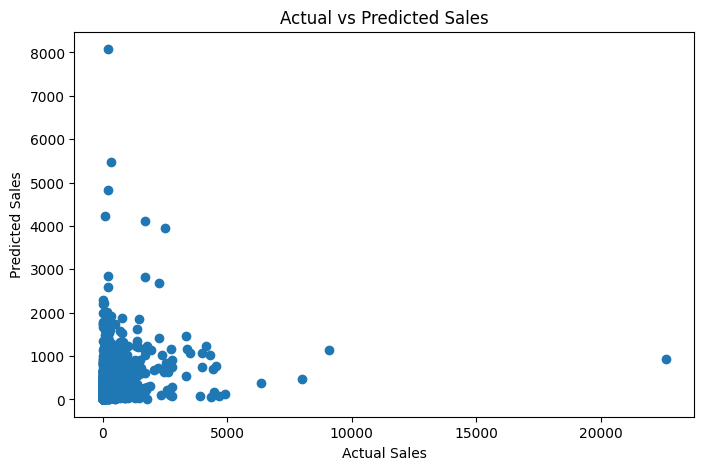

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

##**Feature Importance**

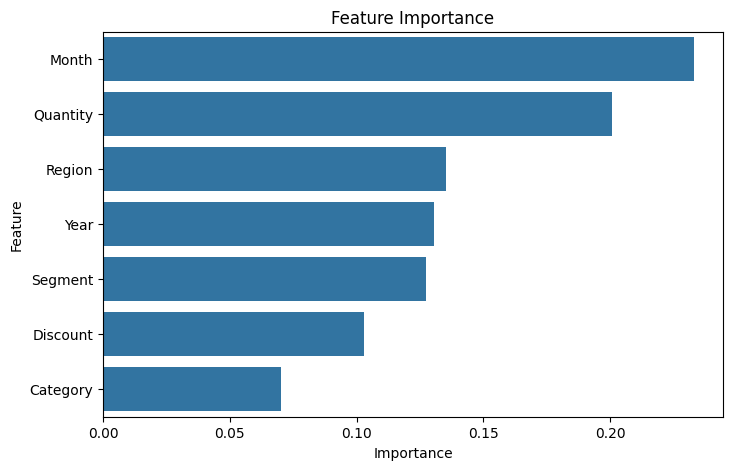

In [ ]:
importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }
)

importance = importance.sort_values(
    by = "Importance",
    ascending = False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x = "Importance",
    y = "Feature",
    data = importance
)

plt.title(
    "Feature Importance"
)

plt.show()

##**Conclusion**

This project successfully developed a predictive analytics model using historical sales data.

The workflow included:

- Data cleaning and preprocessing

- Exploratory data analysis

- Feature engineering

- Machine learning model development

- Model evaluation

- Prediction visualization

The project demonstrates how machine learning techniques can be used to analyze historical patterns and forecast future sales trends.